<a href="https://colab.research.google.com/github/toryor31oct/group15-Fun-Rai-Kwam-plod-Phai/blob/Tang-oh/graph3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# โหลดไฟล์ข้อมูลการเคลม

In [25]:
import pandas as pd

# (มีข้อมูลลูกค้าและกรมธรรม์อยู่แล้ว)
df_claims = pd.read_csv("claims_system.csv")

# ตั้งค่าฟอร์แมตตัวเลข
pd.options.display.float_format = "{:,.2f}".format


# ตั้งคำถามเกี่ยวกับธุรกิจแล้วตอบด้วย pandas
คำถามที่ 1: ประกันแต่ละประเภทมี "ยอดรวมเงินจ่ายสุทธิ" และ "ยอดขอเบิกเฉลี่ย" เท่าใด

คำถามที่ 2: ภาพรวมสถานะการอนุมัติ (Approved vs Rejected) มีจำนวนกี่เคส และจ่ายเงินสุทธิรวมเท่าใด

คำถามที่ 3: เมื่อจำแนกตามประเภทประกัน มีจำนวนเคสที่ผ่านอนุมัติและถูกปฏิเสธอย่างไรบ้าง?

คำถามที่ 4: ผู้รับประโยชน์กลุ่มไหน (บิดา, มารดา, บุตร ฯลฯ) มีจำนวนเคสมากสุด พร้อมยอดจ่ายสูงสุดและค่าเฉลี่ย?

In [26]:
# คำถามที่ 3: เมื่อจำแนกตามประเภทประกัน มีจำนวนเคสที่ผ่านอนุมัติและถูกปฏิเสธอย่างไรบ้าง?

# part1 จำนวนเคสที่ผ่านอนุมัติและถูกปฏิเสธ
q3_df = (df_claims.groupby(["insurance_type", "payment_status"]).agg(
         total_cases = ("claim_id", "count"),
         total_payout = ("net_payout", "sum"),).sort_values(by=["insurance_type", "payment_status"], ascending=False))
print("=== จำนวนเคสและยอดจ่ายรวม ( Completed = ผ่าน | Cancelled = ไม่ผ่าน ) ===")
display(q3_df)

# part2 เหตุผลที่ไม่ผ่าน พร้อมส่วนต่างเงินที่ยื่นเกินวงเงิน
df_rejected = df_claims[df_claims["payment_status"] == "Cancelled"].copy()
df_rejected["excess_amount"] = (df_rejected["claim_amount"] - df_rejected["coverage_limit"])

q3_detail_df = (df_rejected.groupby(["insurance_type", "claim_detail"]).agg(
                rejected_cases = ("claim_id", "count"),
                avg_claim_amount = ("claim_amount", "mean"),
                avg_coverage_limit = ("coverage_limit", "mean"),
                avg_axcess_amount = ("excess_amount", "mean"),).sort_values(by="rejected_cases", ascending=False))

print("\n=== เหตุผลที่ไม่ผ่าน และยอดเงินที่ยื่นเกินวงเงิน ==="
)
display(q3_detail_df)

=== จำนวนเคสและยอดจ่ายรวม ( Completed = ผ่าน | Cancelled = ไม่ผ่าน ) ===


total_cases   total_payout
insurance_type   payment_status                            
ประกันโรคร้ายแรง Paid                     70  81,972,000.00
ประกันอุบัติเหตุ Paid                     68  19,886,779.63
                 Cancelled                 7           0.00
ประกันสุขภาพ     Paid                     63  26,216,579.78
                 Cancelled                17           0.00
ประกันชีวิต      Paid                     75 137,857,500.00


=== เหตุผลที่ไม่ผ่าน และยอดเงินที่ยื่นเกินวงเงิน ===


rejected_cases  \
insurance_type   claim_detail                                                    
ประกันสุขภาพ     ผ่าตัดไส้ติ่งอักเสบฉุกเฉิน                                  6   
                 เข้ารับการรักษาผู้ป่วยใน (IPD) โรคไข้หวัดใหญ่               6   
                 เข้ารับการรักษาผู้ป่วยนอก (OPD) ลำไส้อักเสบ                 5   
ประกันอุบัติเหตุ เข้ารักษาฉุกเฉินจากลื่นล้มหกล้ม                             4   
                 กระดูกข้อเท้าแตกหักจากการเล่นกีฬา                           3   

                                                                avg_claim_amount  \
insurance_type   claim_detail                                                      
ประกันสุขภาพ     ผ่าตัดไส้ติ่งอักเสบฉุกเฉิน                           689,911.16   
                 เข้ารับการรักษาผู้ป่วยใน (IPD) โรคไข้หวัดใหญ่        712,611.01   
                 เข้ารับการรักษาผู้ป่วยนอก (OPD) ลำไส้อักเสบ          538,794.15   
ประกันอุบัติเหตุ เข้ารักษาฉุกเฉินจากลื่นล้มหกล้ม                      537,886.95   
                 กระดูกข้อเท้าแตกหักจากการเล่นกีฬา                    719,952.44   

                                                                avg_coverage_limit  \
insurance_type   claim_detail                                                        
ประกันสุขภาพ     ผ่าตัดไส้ติ่งอักเสบฉุกเฉิน                             675,000.00   
                 เข้ารับการรักษาผู้ป่วยใน (IPD) โรคไข้หวัดใหญ่          650,000.00   
                 เข้ารับการรักษาผู้ป่วยนอก (OPD) ลำไส้อักเสบ            500,000.00   
ประกันอุบัติเหตุ เข้ารักษาฉุกเฉินจากลื่นล้มหกล้ม                        512,500.00   
                 กระดูกข้อเท้าแตกหักจากการเล่นกีฬา                      683,333.33   

                                                                avg_axcess_amount  
insurance_type   claim_detail                                                      
ประกันสุขภาพ     ผ่าตัดไส้ติ่งอักเสบฉุกเฉิน                             14,911.16  
                 เข้ารับการรักษาผู้ป่วยใน (IPD) โรคไข้หวัดใหญ่          62,611.01  
                 เข้ารับการรักษาผู้ป่วยนอก (OPD) ลำไส้อักเสบ            38,794.15  
ประกันอุบัติเหตุ เข้ารักษาฉุกเฉินจากลื่นล้มหกล้ม                        25,386.96  
                 กระดูกข้อเท้าแตกหักจากการเล่นกีฬา                      36,619.11

In [27]:
import matplotlib.pyplot as plt

In [28]:
import numpy as np
import os, shutil
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

In [29]:
# 1. ติดตั้งฟอนต์ภาษาไทย
!apt-get -y install fonts-thai-tlwg

# 2. ล้าง cache ของ matplotlib เพื่ออัปเดตฟอนต์ใหม่
cache_dir = matplotlib.get_cachedir()
if os.path.exists(cache_dir):
    shutil.rmtree(cache_dir)

# 3. ลงทะเบียนฟอนต์ใหม่เข้ากับ FontManager
font_path = '/usr/share/fonts/truetype/tlwg/Loma.ttf'
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)

# 4. ตั้งค่าฟอนต์หลัก
plt.rcParams['font.family'] = 'Loma'
plt.rcParams['axes.unicode_minus'] = False

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-thai-tlwg is already the newest version (1:0.7.3-1).
0 upgraded, 0 newly installed, 0 to remove and 1 not upgraded.


<Figure size 900x500 with 0 Axes>

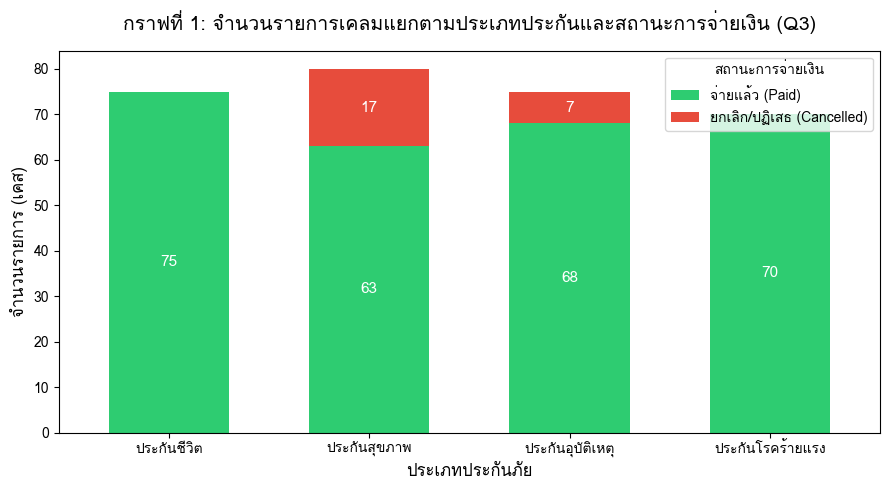

สรุปผลกราฟที่ 1: ประเภทประกันที่มีการอนุมัติจ่ายเงิน (Paid) มากที่สุดคือ ประกันชีวิต จำนวน 75 รายการ


In [30]:
# กราฟที่ 1: Stacked Bar Chart - จำนวน Paid / Cancelled แยกตามประเภทประกัน (กราฟหลัก Q3)
plt.figure(figsize=(9, 5))
status_counts = (
    df_claims.groupby(['insurance_type', 'payment_status'])
    .size()
    .unstack(fill_value=0)
)
cols = [c for c in ['Paid', 'Cancelled'] if c in status_counts.columns]
status_counts = status_counts[cols]

ax1 = status_counts.plot(
    kind='bar',
    stacked=True,
    color=['#2ecc71', '#e74c3c'],
    figsize=(9, 5),
    width=0.6,
)
plt.title(
    'กราฟที่ 1: จำนวนรายการเคลมแยกตามประเภทประกันและสถานะการจ่ายเงิน (Q3)',
    fontsize=14,
    fontweight='bold',
    pad=15,
)
plt.xlabel('ประเภทประกันภัย', fontsize=12)
plt.ylabel('จำนวนรายการ (เคส)', fontsize=12)
plt.legend(
    title='สถานะการจ่ายเงิน',
    labels=['จ่ายแล้ว (Paid)', 'ยกเลิก/ปฏิเสธ (Cancelled)'],
    frameon=True,
)
plt.xticks(rotation=0)

# แสดงตัวเลขบนแท่งกราฟ
for c in ax1.containers:
  for p in c:
    height = p.get_height()
    if height > 0:
      ax1.annotate(
          f'{int(height)}',
          (p.get_x() + p.get_width() / 2., p.get_y() + height / 2.),
          ha='center',
          va='center',
          color='white',
          fontweight='bold',
          fontsize=11,
      )

plt.tight_layout()
plt.show()

# สรุปผลข้อที่ 1
top_paid_type = status_counts['Paid'].idxmax()
top_paid_val = status_counts['Paid'].max()
print(
    f'สรุปผลกราฟที่ 1: ประเภทประกันที่มีการอนุมัติจ่ายเงิน (Paid) มากที่สุดคือ {top_paid_type} จำนวน {top_paid_val} รายการ'
)

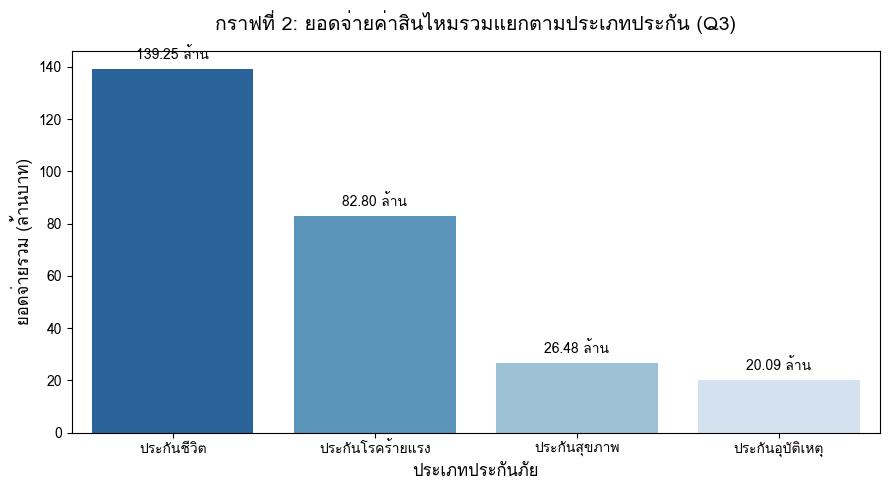

สรุปผลกราฟที่ 2: ประกันภัยที่มียอดจ่ายค่าสินไหมสูงสุดคือ ประกันชีวิต ด้วยยอดจ่ายรวม 139,250,000.00 บาท (139.25 ล้านบาท)


In [31]:
# กราฟที่ 2: Bar Chart - ยอดจ่ายจริงรวม (Paid Amount) แยกตามประเภทประกัน
plt.figure(figsize=(9, 5))
payout_summary = (
    df_claims.groupby('insurance_type')['paid_amount'].sum().reset_index()
)
payout_summary['paid_amount_m'] = payout_summary['paid_amount'] / 1e6
payout_summary = payout_summary.sort_values(
    by='paid_amount_m', ascending=False
)

ax2 = sns.barplot(
    data=payout_summary,
    x='insurance_type',
    y='paid_amount_m',
    hue='insurance_type',
    palette='Blues_r',
    legend=False,
)
plt.title(
    'กราฟที่ 2: ยอดจ่ายค่าสินไหมรวมแยกตามประเภทประกัน (Q3)',
    fontsize=14,
    fontweight='bold',
    pad=15,
)
plt.xlabel('ประเภทประกันภัย', fontsize=12)
plt.ylabel('ยอดจ่ายรวม (ล้านบาท)', fontsize=12)

# แสดงตัวเลขยอดเงินบนแท่งกราฟ
for p in ax2.patches:
  val = p.get_height()
  ax2.annotate(
      f'{val:,.2f} ล้าน',
      (p.get_x() + p.get_width() / 2., val),
      ha='center',
      va='bottom',
      fontsize=10,
      fontweight='bold',
      xytext=(0, 5),
      textcoords='offset points',
  )

plt.tight_layout()
plt.show()

# สรุปผลข้อที่ 2 (ดึงค่าแบบ iloc[0] ตามโครงสร้าง)
print(
    f"สรุปผลกราฟที่ 2: ประกันภัยที่มียอดจ่ายค่าสินไหมสูงสุดคือ {payout_summary.iloc[0]['insurance_type']} ด้วยยอดจ่ายรวม {payout_summary.iloc[0]['paid_amount']:,.2f} บาท ({payout_summary.iloc[0]['paid_amount_m']:.2f} ล้านบาท)"
)

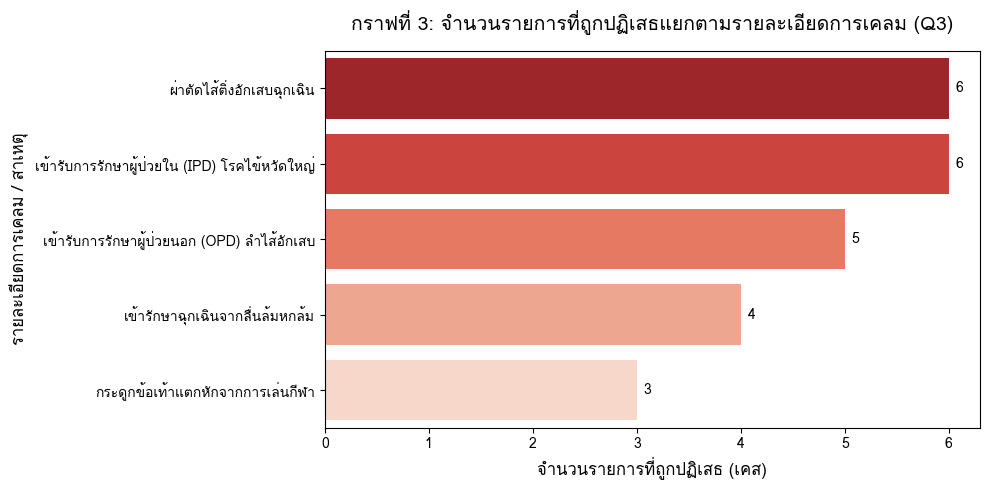

สรุปผลกราฟที่ 3: สาเหตุที่ถูกปฏิเสธการเคลมมากที่สุดคือ ผ่าตัดไส้ติ่งอักเสบฉุกเฉิน จำนวน 6 รายการ


In [32]:
rejected_df = df_claims[df_claims['payment_status'] == 'Cancelled'].copy()

detail_counts = rejected_df['claim_detail'].value_counts().reset_index()
detail_counts.columns = ['claim_detail', 'count']

plt.figure(figsize=(10, 5))
ax3 = sns.barplot(
    data=detail_counts,
    y='claim_detail',
    x='count',
    hue='claim_detail',
    palette='Reds_r',
    legend=False,
)
plt.title(
    'กราฟที่ 3: จำนวนรายการที่ถูกปฏิเสธแยกตามรายละเอียดการเคลม (Q3)',
    fontsize=14,
    fontweight='bold',
    pad=15,
)
plt.xlabel('จำนวนรายการที่ถูกปฏิเสธ (เคส)', fontsize=12)
plt.ylabel('รายละเอียดการเคลม / สาเหตุ', fontsize=12)

# แสดงตัวเลขจำนวนเคสตรงปลายแท่งกราฟ
for p in ax3.patches:
  val = p.get_width()
  ax3.annotate(
      f'{int(val)}',
      (val, p.get_y() + p.get_height() / 2.),
      ha='left',
      va='center',
      fontsize=10,
      fontweight='bold',
      xytext=(5, 0),
      textcoords='offset points',
  )

plt.tight_layout()
plt.show()

# สรุปผลข้อที่ 3
print(
    f"สรุปผลกราฟที่ 3: สาเหตุที่ถูกปฏิเสธการเคลมมากที่สุดคือ {detail_counts.iloc[0]['claim_detail']} จำนวน {detail_counts.iloc[0]['count']} รายการ"
)